In [30]:
#pip install gensim

In [31]:
from gensim.models import Word2Vec

sentences = [
     {"king","queen","man","woman"},
     {"king","man","royal"},
     {"queen","woman","royal"},
     {"apple","mango","fruit"},
     {"apple","mango","sweet"},
     {"computer","keyboard","technology"},
     {"computer","keyboard","device"}
]

model = Word2Vec(
    sentences,
    vector_size=4,
    window=2,
    min_count=1,
    workers=1,
    epochs=100
)

print(model.wv["king"])
print(model.wv["queen"])
print(model.wv["computer"])

[ 0.15935078 -0.08527994 -0.02400814  0.1442788 ]
[ 0.23890932 -0.18319948 -0.05875269 -0.04858635]
[-0.2320811  -0.17825451  0.16106921  0.22397873]


In [32]:
glove_content =""" king 0.50 0.70 -0.60 0.10
queen 0.55 0.75 -0.65 0.12
man 0.40 0.50 -0.30 0.05
woman 0.45 0.55 -0.35 0.07
apple 0.90 0.10 0.05 -0.20
mango 0.88 0.12 0.08 -0.18
computer -0.50 -0.40 0.80 0.90
keyboard -0.55 -0.42 0.85 0.92
 """

In [33]:
import numpy as np
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

In [34]:
glove2word2vec("test_glove.txt","test_wv.txt")

C:\Users\UserG\AppData\Local\Temp\ipykernel_2044\1509184360.py:1: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec("test_glove.txt","test_wv.txt")


(8, 4)

In [35]:
model= KeyedVectors.load_word2vec_format("test_wv.txt",binary=False)

In [36]:
model

In [37]:
model.similarity('king', 'queen')

np.float32(0.9998945)

In [40]:
model.similarity('computer', 'woman')

np.float32(-0.61038744)

In [41]:
model.similarity('computer', 'woman')

np.float32(-0.61038744)

In [ ]:
#

In [ ]:
model.similarity('computer', 'keyboard')

#### Analogy : King - Man + Woman = ?

In [43]:
model.most_similar(positive=['king','queen'], negative=['man'],topn=5) #top n=5

[('woman', 0.9453907012939453),
 ('apple', 0.3686526417732239),
 ('mango', 0.3609870672225952),
 ('computer', -0.6391991376876831),
 ('keyboard', -0.6533379554748535)]

In [44]:
model.most_similar('keyboard')[0]

('computer', 0.9996709227561951)

In [45]:
model.doesnt_match(['computer','keyboard','mango'])

'mango'

#### visualize

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [49]:
pca = PCA(n_components=2,random_state=0)

In [50]:
vectors_2d = pca.fit_transform(model.vectors)
vectors_2d.shape

(8, 2)

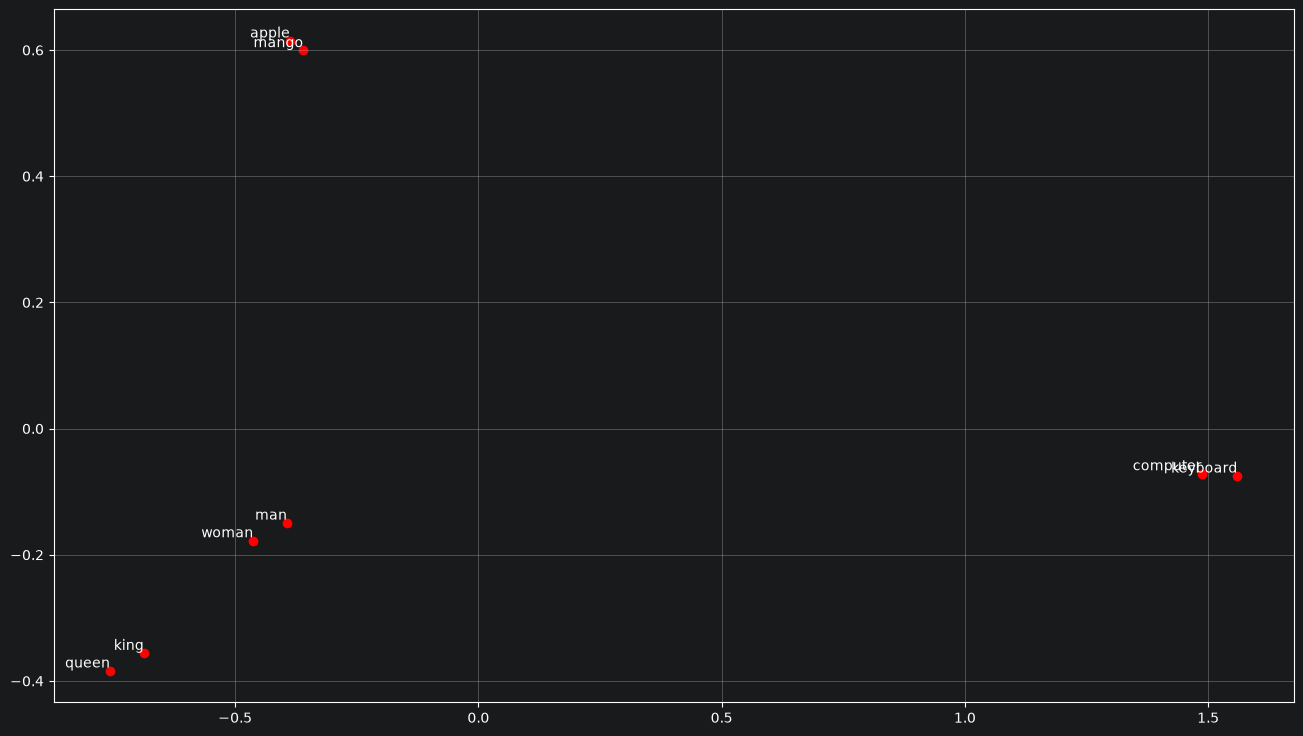

In [51]:
plt.figure(figsize =(16,9))
plt.scatter(vectors_2d[:,0], vectors_2d[:,1], color = 'r')
for i , word in enumerate(model.index_to_key):
  plt.annotate(word,xy=(vectors_2d[i,0],vectors_2d[i,1]),
               ha='right',va='bottom')
plt.grid()